# Data Before Doors – University Enrollment Prediction

## Importing Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## Loading the Dataset

In [7]:
from pathlib import Path

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

data_folder = project_root / "data"
csv_files = list(data_folder.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(
        "No CSV file found"
    )

data_path = csv_files[0]
df = pd.read_csv(data_path, sep=";")

print("Dataset:", data_path.name)
print("Shape:", df.shape)


Dataset: data.csv
Shape: (4424, 37)


## Understanding the Dataset


In [8]:
# First five rows
df.head()


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [9]:
# Number of rows and columns
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 4424
Columns: 37


In [10]:
# Column names
for column in df.columns:
    print(column)


Marital status
Application mode
Application order
Course
Daytime/evening attendance	
Previous qualification
Previous qualification (grade)
Nacionality
Mother's qualification
Father's qualification
Mother's occupation
Father's occupation
Admission grade
Displaced
Educational special needs
Debtor
Tuition fees up to date
Gender
Scholarship holder
Age at enrollment
International
Curricular units 1st sem (credited)
Curricular units 1st sem (enrolled)
Curricular units 1st sem (evaluations)
Curricular units 1st sem (approved)
Curricular units 1st sem (grade)
Curricular units 1st sem (without evaluations)
Curricular units 2nd sem (credited)
Curricular units 2nd sem (enrolled)
Curricular units 2nd sem (evaluations)
Curricular units 2nd sem (approved)
Curricular units 2nd sem (grade)
Curricular units 2nd sem (without evaluations)
Unemployment rate
Inflation rate
GDP
Target


In [11]:
# Data types and non-null information
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [12]:
# Basic numerical summary
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance\t,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


## Check the Target Variable

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


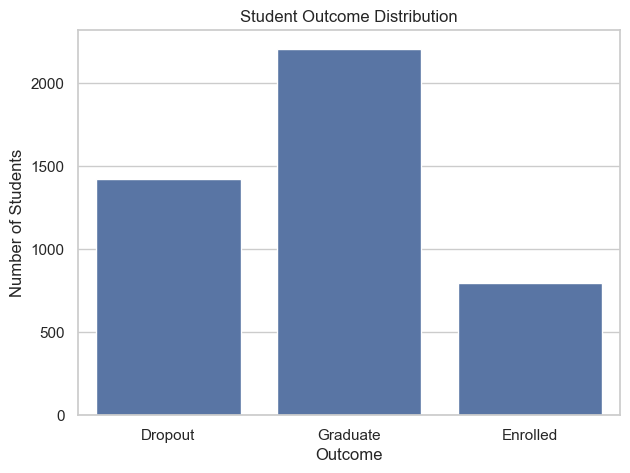

In [13]:
target_counts = df["Target"].value_counts()

print(target_counts)

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Target")
plt.title("Student Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Students")
plt.show()


In [14]:
# Missing values
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

missing_values[missing_values > 0]


Total missing values: 0


Series([], dtype: int64)

In [15]:
# Duplicate rows
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)


Duplicate rows: 0


## Basic Outlier Analysis

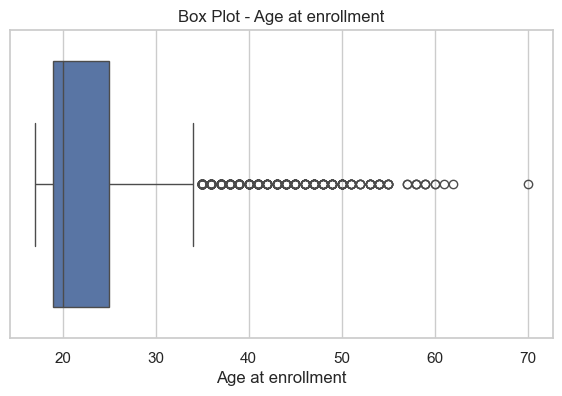

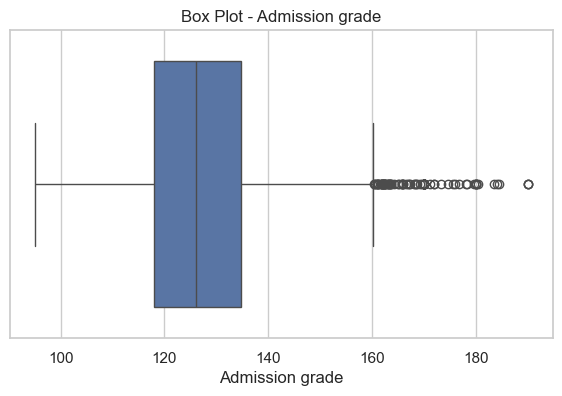

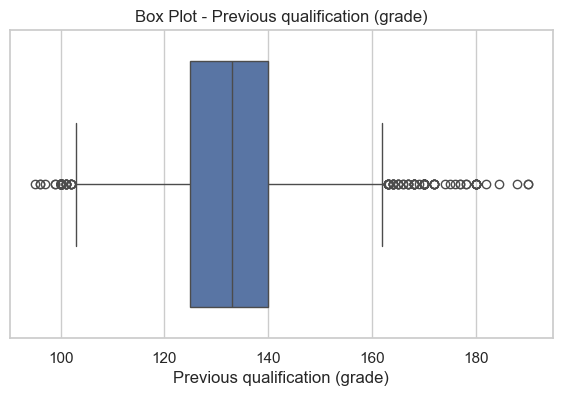

In [16]:
numeric_features_for_eda = [
    "Age at enrollment",
    "Admission grade",
    "Previous qualification (grade)"
]

for column in numeric_features_for_eda:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df[column])
    plt.title(f"Box Plot - {column}")
    plt.xlabel(column)
    plt.show()


## Exploratory Data Analysis

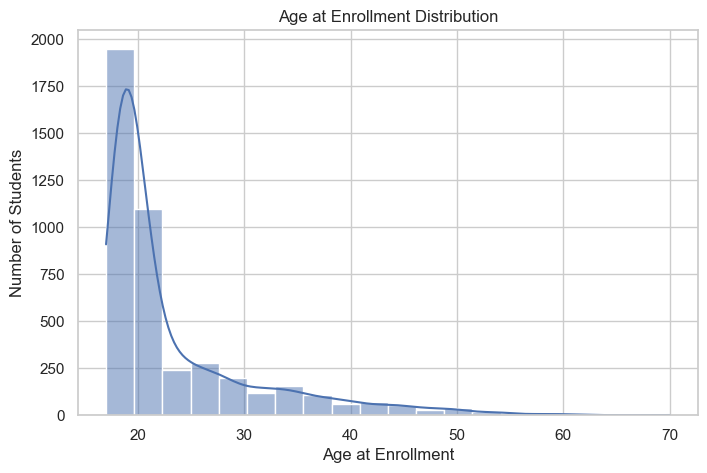

In [17]:
# Age distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age at enrollment", bins=20, kde=True)
plt.title("Age at Enrollment Distribution")
plt.xlabel("Age at Enrollment")
plt.ylabel("Number of Students")
plt.show()


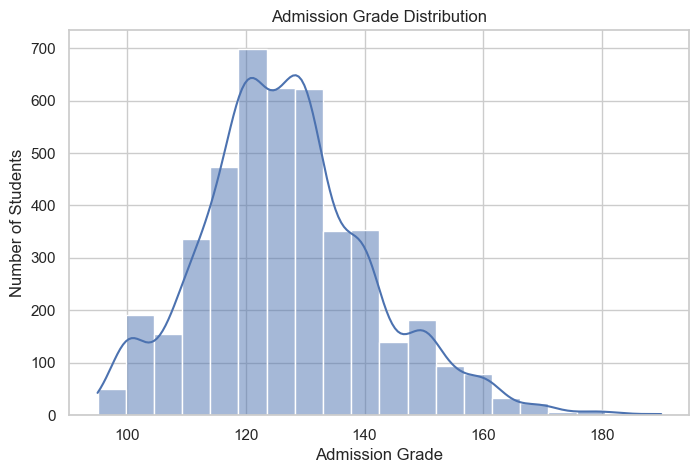

In [18]:
# Admission grade distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Admission grade", bins=20, kde=True)
plt.title("Admission Grade Distribution")
plt.xlabel("Admission Grade")
plt.ylabel("Number of Students")
plt.show()


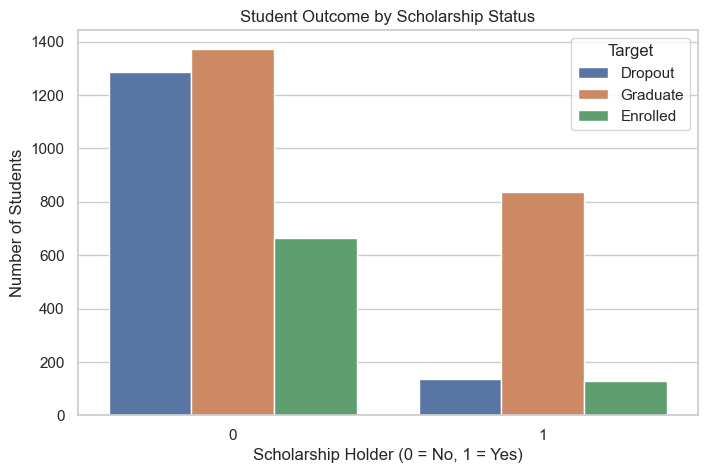

In [19]:
# Outcome by scholarship status

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Scholarship holder", hue="Target")
plt.title("Student Outcome by Scholarship Status")
plt.xlabel("Scholarship Holder (0 = No, 1 = Yes)")
plt.ylabel("Number of Students")
plt.show()


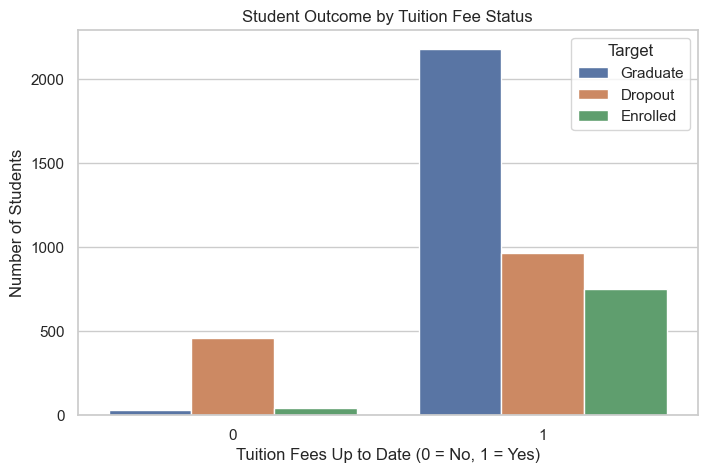

In [20]:
# Outcome by tuition-fee status

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Tuition fees up to date", hue="Target")
plt.title("Student Outcome by Tuition Fee Status")
plt.xlabel("Tuition Fees Up to Date (0 = No, 1 = Yes)")
plt.ylabel("Number of Students")
plt.show()


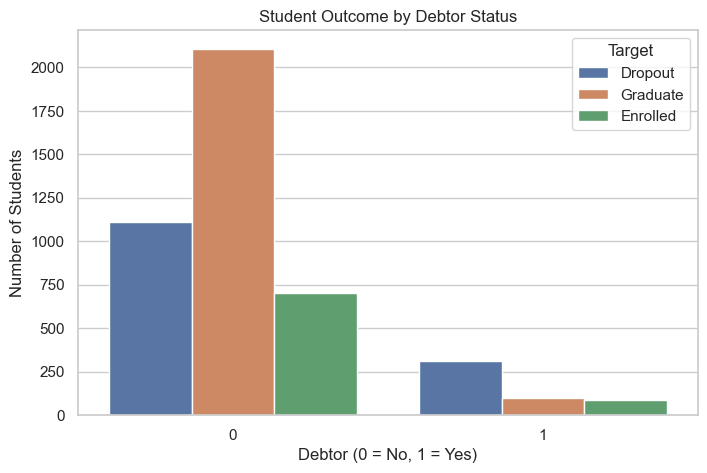

In [21]:
# Outcome by debtor status

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Debtor", hue="Target")
plt.title("Student Outcome by Debtor Status")
plt.xlabel("Debtor (0 = No, 1 = Yes)")
plt.ylabel("Number of Students")
plt.show()


## Selecting Features and Target

In [22]:
selected_features = [
    "Age at enrollment",
    "Admission grade",
    "Previous qualification (grade)",
    "Scholarship holder",
    "Tuition fees up to date",
    "Debtor",
    "Gender",
    "International"
]

X = df[selected_features].copy()
y = df["Target"].copy()

print("Features:")
print(selected_features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)


Features:
['Age at enrollment', 'Admission grade', 'Previous qualification (grade)', 'Scholarship holder', 'Tuition fees up to date', 'Debtor', 'Gender', 'International']

X shape: (4424, 8)
y shape: (4424,)


## Train/Test Split


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (3539, 8)
Testing data: (885, 8)


## Converting Categorical Features to Numbers


In [25]:
categorical_features = [
    "Gender",
    "International"
]

X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_features,
    drop_first=True
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_features,
    drop_first=True
)

X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

print("Training columns:", X_train_encoded.columns.tolist())
print("Encoded training shape:", X_train_encoded.shape)


Training columns: ['Age at enrollment', 'Admission grade', 'Previous qualification (grade)', 'Scholarship holder', 'Tuition fees up to date', 'Debtor', 'Gender_1', 'International_1']
Encoded training shape: (3539, 8)


## Scaling Numerical Features

In [26]:
numeric_features = [
    "Age at enrollment",
    "Admission grade",
    "Previous qualification (grade)"
]

scaler = StandardScaler()

X_train_encoded[numeric_features] = scaler.fit_transform(
    X_train_encoded[numeric_features]
)

X_test_encoded[numeric_features] = scaler.transform(
    X_test_encoded[numeric_features]
)

print("Scaling completed.")


Scaling completed.


## Logistic Regression

In [27]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

logistic_model.fit(X_train_encoded, y_train)

logistic_pred = logistic_model.predict(X_test_encoded)

print("Logistic Regression trained successfully.")


Logistic Regression trained successfully.


In [28]:
logistic_accuracy = accuracy_score(y_test, logistic_pred)
logistic_precision = precision_score(
    y_test, logistic_pred, average="macro", zero_division=0
)
logistic_recall = recall_score(
    y_test, logistic_pred, average="macro", zero_division=0
)
logistic_f1 = f1_score(
    y_test, logistic_pred, average="macro", zero_division=0
)

print("Logistic Regression")
print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1-score :", round(logistic_f1, 4))


Logistic Regression
Accuracy : 0.6203
Precision: 0.6383
Recall   : 0.4834
F1-score : 0.4474


## Decision Tree

In [29]:
decision_tree = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

decision_tree.fit(X_train_encoded, y_train)

tree_pred = decision_tree.predict(X_test_encoded)

print("Decision Tree trained successfully.")


Decision Tree trained successfully.


In [30]:
tree_accuracy = accuracy_score(y_test, tree_pred)
tree_precision = precision_score(
    y_test, tree_pred, average="macro", zero_division=0
)
tree_recall = recall_score(
    y_test, tree_pred, average="macro", zero_division=0
)
tree_f1 = f1_score(
    y_test, tree_pred, average="macro", zero_division=0
)

print("Decision Tree")
print("Accuracy :", round(tree_accuracy, 4))
print("Precision:", round(tree_precision, 4))
print("Recall   :", round(tree_recall, 4))
print("F1-score :", round(tree_f1, 4))


Decision Tree
Accuracy : 0.5186
Precision: 0.4649
Recall   : 0.4666
F1-score : 0.4653


## Random Forest

In [31]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE
)

random_forest.fit(X_train_encoded, y_train)

forest_pred = random_forest.predict(X_test_encoded)

print("Random Forest trained successfully.")


Random Forest trained successfully.


In [32]:
forest_accuracy = accuracy_score(y_test, forest_pred)
forest_precision = precision_score(
    y_test, forest_pred, average="macro", zero_division=0
)
forest_recall = recall_score(
    y_test, forest_pred, average="macro", zero_division=0
)
forest_f1 = f1_score(
    y_test, forest_pred, average="macro", zero_division=0
)

print("Random Forest")
print("Accuracy :", round(forest_accuracy, 4))
print("Precision:", round(forest_precision, 4))
print("Recall   :", round(forest_recall, 4))
print("F1-score :", round(forest_f1, 4))


Random Forest
Accuracy : 0.5672
Precision: 0.4856
Recall   : 0.4853
F1-score : 0.4823


## Comparing the Models

In [33]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        forest_accuracy
    ],
    "Precision": [
        logistic_precision,
        tree_precision,
        forest_precision
    ],
    "Recall": [
        logistic_recall,
        tree_recall,
        forest_recall
    ],
    "F1-score": [
        logistic_f1,
        tree_f1,
        forest_f1
    ]
})

results = results.sort_values("F1-score", ascending=False).reset_index(drop=True)

display(
    results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}"
    })
)


,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.5672,0.4856,0.4853,0.4823
1,Decision Tree,0.5186,0.4649,0.4666,0.4653
2,Logistic Regression,0.6203,0.6383,0.4834,0.4474


## Confusion Matrix

Best model based on macro F1-score: Random Forest


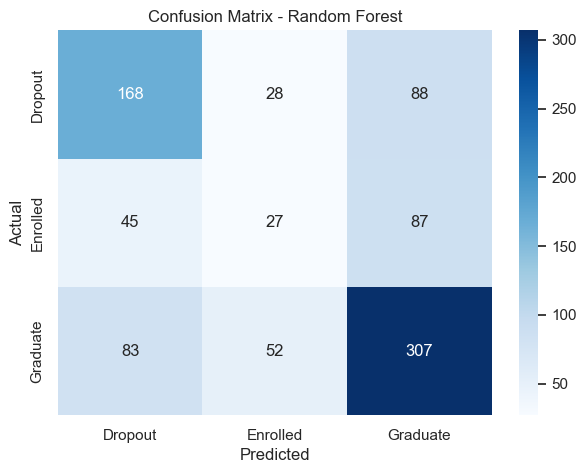

In [34]:
best_model_name = results.loc[0, "Model"]

predictions = {
    "Logistic Regression": logistic_pred,
    "Decision Tree": tree_pred,
    "Random Forest": forest_pred
}

best_predictions = predictions[best_model_name]

print("Best model based on macro F1-score:", best_model_name)

cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [35]:
print(f"Classification Report - {best_model_name}\n")

print(
    classification_report(
        y_test,
        best_predictions,
        zero_division=0
    )
)


Classification Report - Random Forest

              precision    recall  f1-score   support

     Dropout       0.57      0.59      0.58       284
    Enrolled       0.25      0.17      0.20       159
    Graduate       0.64      0.69      0.66       442

    accuracy                           0.57       885
   macro avg       0.49      0.49      0.48       885
weighted avg       0.55      0.57      0.55       885



## Final Model

In [36]:
if best_model_name == "Logistic Regression":
    final_model = logistic_model
elif best_model_name == "Decision Tree":
    final_model = decision_tree
else:
    final_model = random_forest

print("Final model:", best_model_name)


Final model: Random Forest


## Feature Importance

,Feature,Importance
1,Admission grade,0.386082
2,Previous qualification (grade),0.233804
0,Age at enrollment,0.185347
4,Tuition fees up to date,0.084211
3,Scholarship holder,0.045572
6,Gender_1,0.028924
5,Debtor,0.028346
7,International_1,0.007715


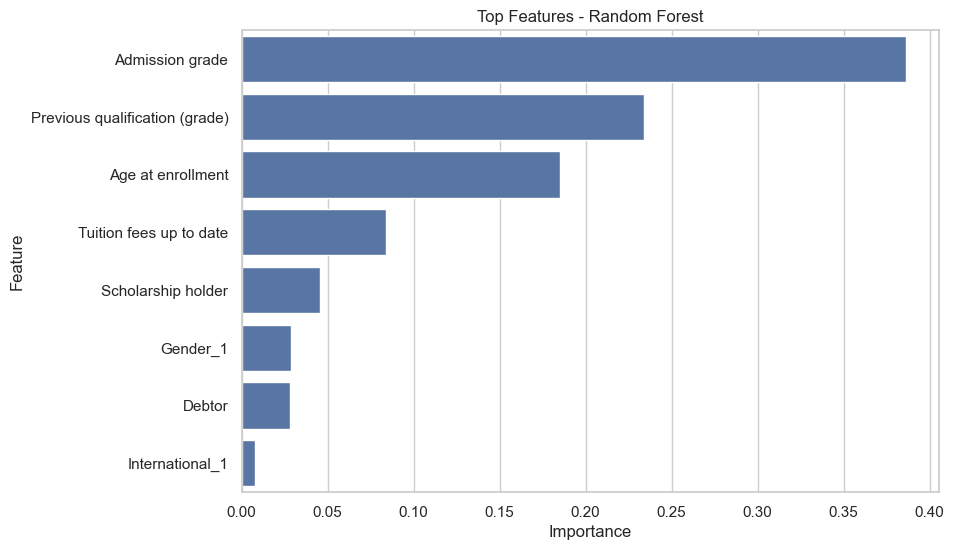

In [38]:
if hasattr(final_model, "feature_importances_"):
    feature_importance = pd.DataFrame({
        "Feature": X_train_encoded.columns,
        "Importance": final_model.feature_importances_
    }).sort_values("Importance", ascending=False)

    display(feature_importance)

    plt.figure(figsize=(9, 6))
    sns.barplot(
        data=feature_importance.head(10),
        x="Importance",
        y="Feature"
    )
    plt.title(f"Top Features - {best_model_name}")
    plt.show()
else:
    print(
        "The selected model does not provide feature importance"
    )


## Saving the Final Model

In [39]:
model_package = {
    "model": final_model,
    "scaler": scaler,
    "numeric_features": numeric_features,
    "feature_columns": X_train_encoded.columns.tolist(),
    "selected_features": selected_features
}

models_folder = project_root / "models"
models_folder.mkdir(exist_ok=True)

model_path = models_folder / "final_model.pkl"

joblib.dump(model_package, model_path)

print("Model saved to:", model_path)


Model saved to: C:\Users\Akshat\OneDrive\Desktop\Ankit_Coding stuff\Machine Learning Projects\Data Before Doors - Copy\models\final_model.pkl


## Loading the Saved Model

In [40]:
loaded_package = joblib.load(model_path)

loaded_model = loaded_package["model"]

loaded_predictions = loaded_model.predict(X_test_encoded)

print(
    "Loaded model predictions match the original predictions:",
    np.array_equal(best_predictions, loaded_predictions)
)


Loaded model predictions match the original predictions: True
